# PronÃ³stico semanal de concentraciÃ³n de NOx en Angamos 1

**Trabajo final - Series de Tiempo**
**Equipo:** Hans Engelmann, Jessica Anaid Aguilar MejÃ­a, MatÃ­as NicolÃ¡s GarcÃ­a Garcete y Guillermo Eder LÃ³pez Rojas
**Estado:** prototipo reproducible construido desde la entrega final hacia el anÃ¡lisis.

Este notebook contiene la ruta completa exigida por la pauta: contexto, preparaciÃ³n de datos, anÃ¡lisis exploratorio, comparaciÃ³n temporal, diagnÃ³stico, prueba final y pronÃ³stico con intervalos.

## 1. Problema y objetivo

La fuente es el sistema SNIFA de la Superintendencia del Medio Ambiente. Se estudian registros horarios reportados para la central `ANGAMOS`, unidad `ANGAMOS 1`, y la variable continua `CONCENTRACION_NOX_MG_NM3`.

**Objetivo general:** modelar y pronosticar la concentraciÃ³n semanal media de NOx de Angamos 1, comparando modelos de series de tiempo y generando un pronÃ³stico de ocho semanas con intervalos del 95%.

La magnitud analizada es una **concentraciÃ³n en mg/NmÂ³**; no corresponde a masa total emitida ni debe expresarse en toneladas.

## 2. DiseÃ±o previo del anÃ¡lisis

- Periodo disponible localmente: 1 de enero de 2020 a 30 de septiembre de 2025.
- Frecuencia original: horaria.
- Frecuencia analÃ­tica: semanal, con cierre en domingo.
- Regla de calidad: dato NOx medido (`TIPO_DATO_NOX` comienza por `DM`) y semana con al menos 75% de 168 horas.
- VacÃ­os: interpolaciÃ³n temporal limitada a un mÃ¡ximo de dos semanas consecutivas.
- ValidaciÃ³n: 32 semanas.
- Prueba final: Ãºltimas 8 semanas, utilizadas una sola vez.
- Horizonte final: 8 semanas.

Las transformaciones, imputaciones y modelos se ajustan sin utilizar informaciÃ³n de la prueba final para seleccionar el modelo.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image
from statsmodels.tsa.stattools import adfuller

ROOT = Path.cwd().resolve()
if ROOT.name == "prototipo_entrega":
    PROTO = ROOT
    PROJECT_ROOT = ROOT.parent
else:
    PROJECT_ROOT = ROOT
    PROTO = ROOT / "prototipo_entrega"

DATA = PROTO / "data"
TABLES = PROTO / "resultados" / "tablas"
FIGURES = PROTO / "resultados" / "figuras"

H_VALIDACION = 32
H_PRUEBA = 8
H_PRONOSTICO = 8
PERIODO_ESTACIONAL = 52

## 3. AuditorÃ­a y construcciÃ³n de la base

La siguiente celda vuelve a leer los 23 CSV por bloques, filtra Angamos 1 y genera las bases reducidas. Su ejecuciÃ³n tarda aproximadamente uno o dos minutos y evita cargar cerca de 3 GB simultÃ¡neamente.

Para una revisiÃ³n rÃ¡pida puede omitirse, porque los resultados ya fueron exportados en `prototipo_entrega/data/` y `prototipo_entrega/resultados/tablas/`.

In [2]:
# Descomentar para reconstruir la base desde los CSV originales.
# %run ../ejecutar_auditoria.py

In [3]:
resumen_auditoria = json.loads(
    (TABLES / "resumen_auditoria.json").read_text(encoding="utf-8")
)
cobertura_anual = pd.read_csv(TABLES / "01_cobertura_anual.csv")
tipo_dato = pd.read_csv(TABLES / "03_tipo_dato_nox.csv")
estado_uge = pd.read_csv(TABLES / "04_estado_uge.csv")

display(pd.Series(resumen_auditoria, name="resultado"))
display(cobertura_anual)
display(tipo_dato)
display(estado_uge)

archivos                                           23
periodo_archivos                     [2020-1, 2025-3]
registros_angamos                               50400
fechas_invalidas                                    0
duplicados_fecha_hora                               0
valores_nox_numericos                           50400
mediciones_validas                              48574
semanas_totales                                   301
semanas_modelamiento                              289
porcentaje_semanas_utilizables                  96.01
fecha_min                         2020-01-01 00:00:00
fecha_max                         2025-09-30 23:00:00
Name: resultado, dtype: object

,anio,registros,horas_unicas,valores_nox,mediciones_validas,fecha_inicio,fecha_fin
0,2020,8784,8784,8784,8514,2020-01-01,2020-12-31 23:00:00
1,2021,8760,8760,8760,8284,2021-01-01,2021-12-31 23:00:00
2,2022,8760,8760,8760,8396,2022-01-01,2022-12-31 23:00:00
3,2023,8760,8760,8760,8398,2023-01-01,2023-12-31 23:00:00
4,2024,8784,8784,8784,8651,2024-01-01,2024-12-31 23:00:00
5,2025,6552,6552,6552,6331,2025-01-01,2025-09-30 23:00:00


,tipo_dato_nox,n,porcentaje
0,DM,48574,96.376984
1,DS,1826,3.623016


,estado_uge,n,porcentaje
0,RE,47208,93.666667
1,HE,1310,2.599206
2,FA,1081,2.144841
3,DP,394,0.781746
4,DNP,241,0.478175
5,HA,166,0.329365


### Resultado de la auditorÃ­a

Se encontraron 50.400 observaciones horarias continuas, ninguna fecha invÃ¡lida y ningÃºn duplicado fecha-hora. El 96,38% de los registros corresponde a cÃ³digos de mediciÃ³n (`DM`), mientras que 3,62% corresponde a datos sustituidos (`DS`).

La cobertura permite continuar: 289 de las 301 semanas inicialmente formadas superaron simultÃ¡neamente las reglas de cobertura y borde. Para mantener un Ã­ndice semanal regular se excluyeron las dos semanas parciales de los extremos y se interpolaron diez semanas interiores con cobertura inferior al 75%; los vacÃ­os fueron aislados o de un mÃ¡ximo de dos semanas.

In [4]:
semanal = pd.read_csv(
    DATA / "angamos1_nox_semanal_modelo.csv",
    parse_dates=["semana_fin"]
).set_index("semana_fin")

assert semanal.index.is_monotonic_increasing
assert semanal.index.to_series().diff().dropna().eq(pd.Timedelta(days=7)).all()
assert semanal["nox_modelo_mg_nm3"].notna().all()

print("Semanas:", len(semanal))
print("Semanas imputadas:", int(semanal["valor_imputado"].sum()))
display(semanal.head())

Semanas: 299
Semanas imputadas: 10


,horas_validas,nox_media_mg_nm3,nox_mediana_mg_nm3,nox_sd_mg_nm3,nox_min_mg_nm3,nox_max_mg_nm3,horas_esperadas,cobertura,semana_utilizable,semana_completa_en_periodo,usar_modelamiento,valor_observado_mg_nm3,valor_imputado,nox_modelo_mg_nm3
semana_fin,,,,,,,,,,,,,,
2020-01-12,164,313.305945,306.957001,33.236959,259.351013,419.552002,168,0.976190,True,True,True,313.305945,False,313.305945
2020-01-19,161,309.019093,303.806000,28.570807,270.040009,408.355988,168,0.958333,True,True,True,309.019093,False,309.019093
2020-01-26,148,356.078129,358.057495,37.991371,294.877991,428.488007,168,0.880952,True,True,True,356.078129,False,356.078129
2020-02-02,166,334.356626,330.459000,26.729993,283.459991,406.763000,168,0.988095,True,True,True,334.356626,False,334.356626
2020-02-09,167,325.446917,325.773987,58.817038,233.460999,561.830017,168,0.994048,True,True,True,325.446917,False,325.446917


## 4. AnÃ¡lisis exploratorio

Se revisan nivel, variabilidad, posibles cambios estructurales, estacionalidad anual y autocorrelaciÃ³n. Las figuras se guardan separadamente para poder reutilizarlas en el informe ejecutivo.

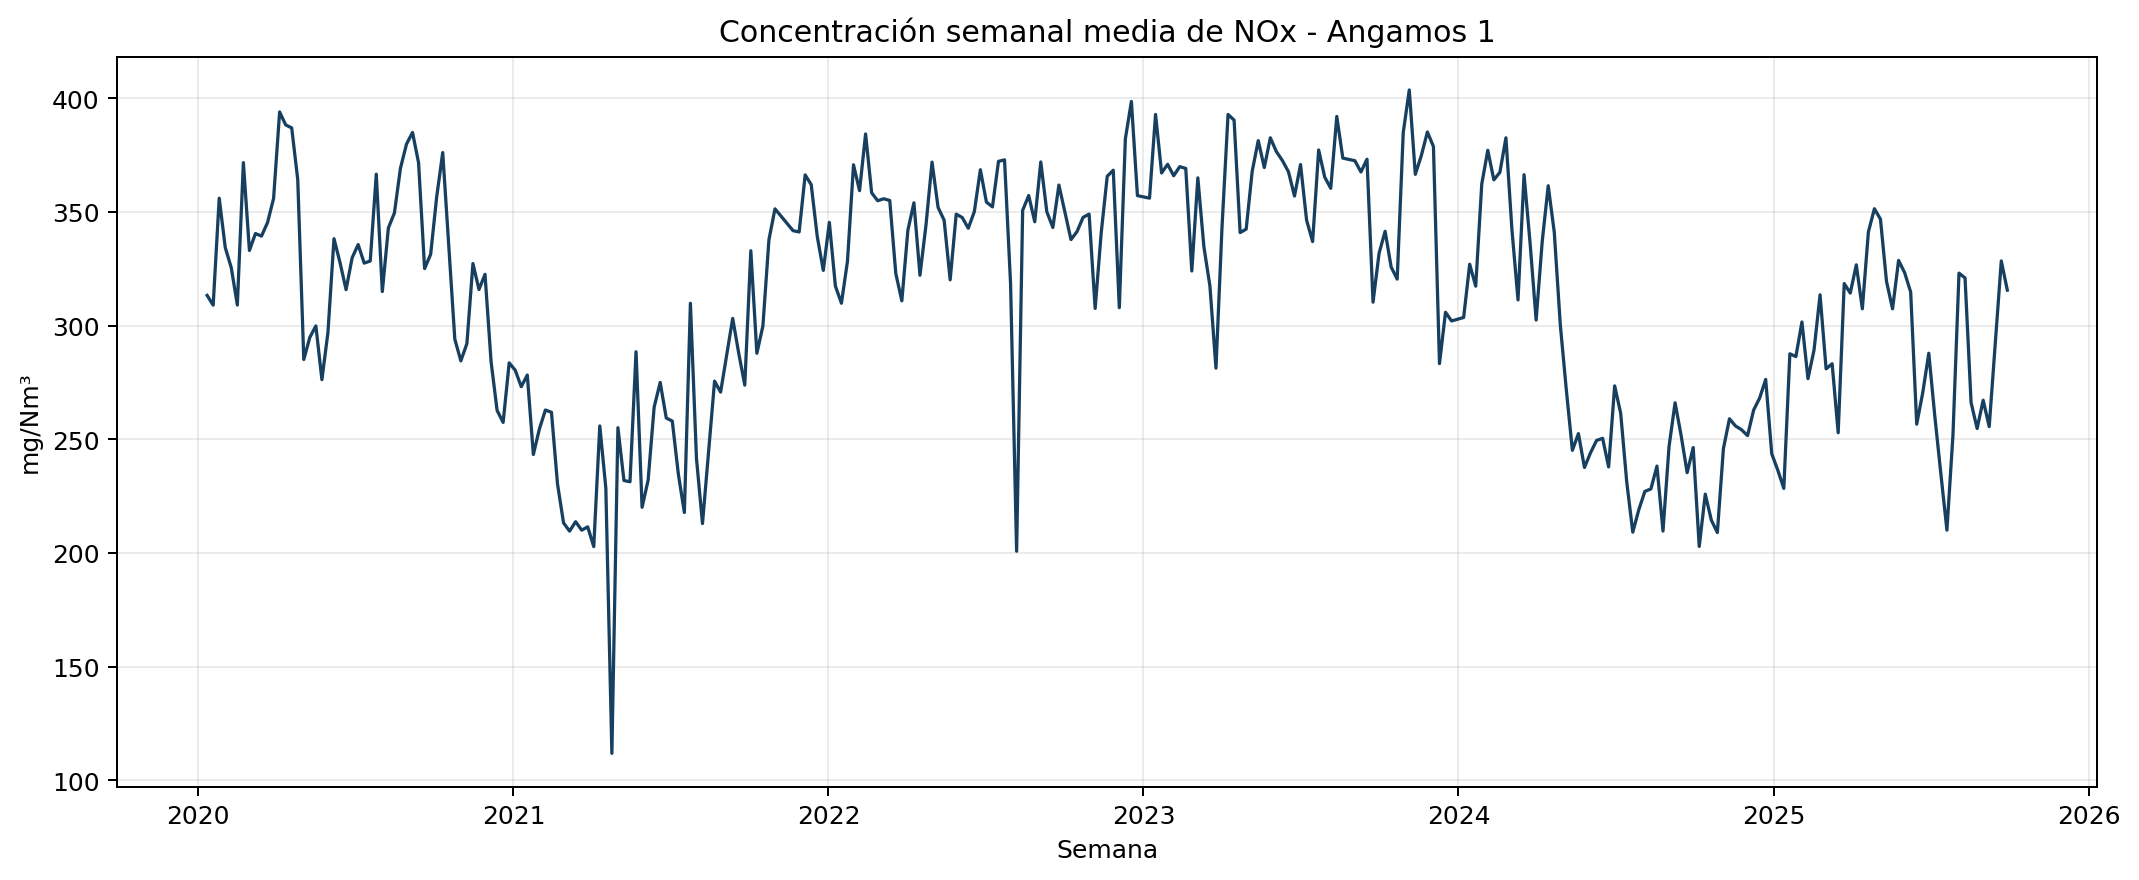

,NOx mg/NmÂ³
count,299.000000
mean,312.240101
std,52.683122
min,111.902796
25%,270.662898
50%,323.124400
75%,355.442415
max,403.672503


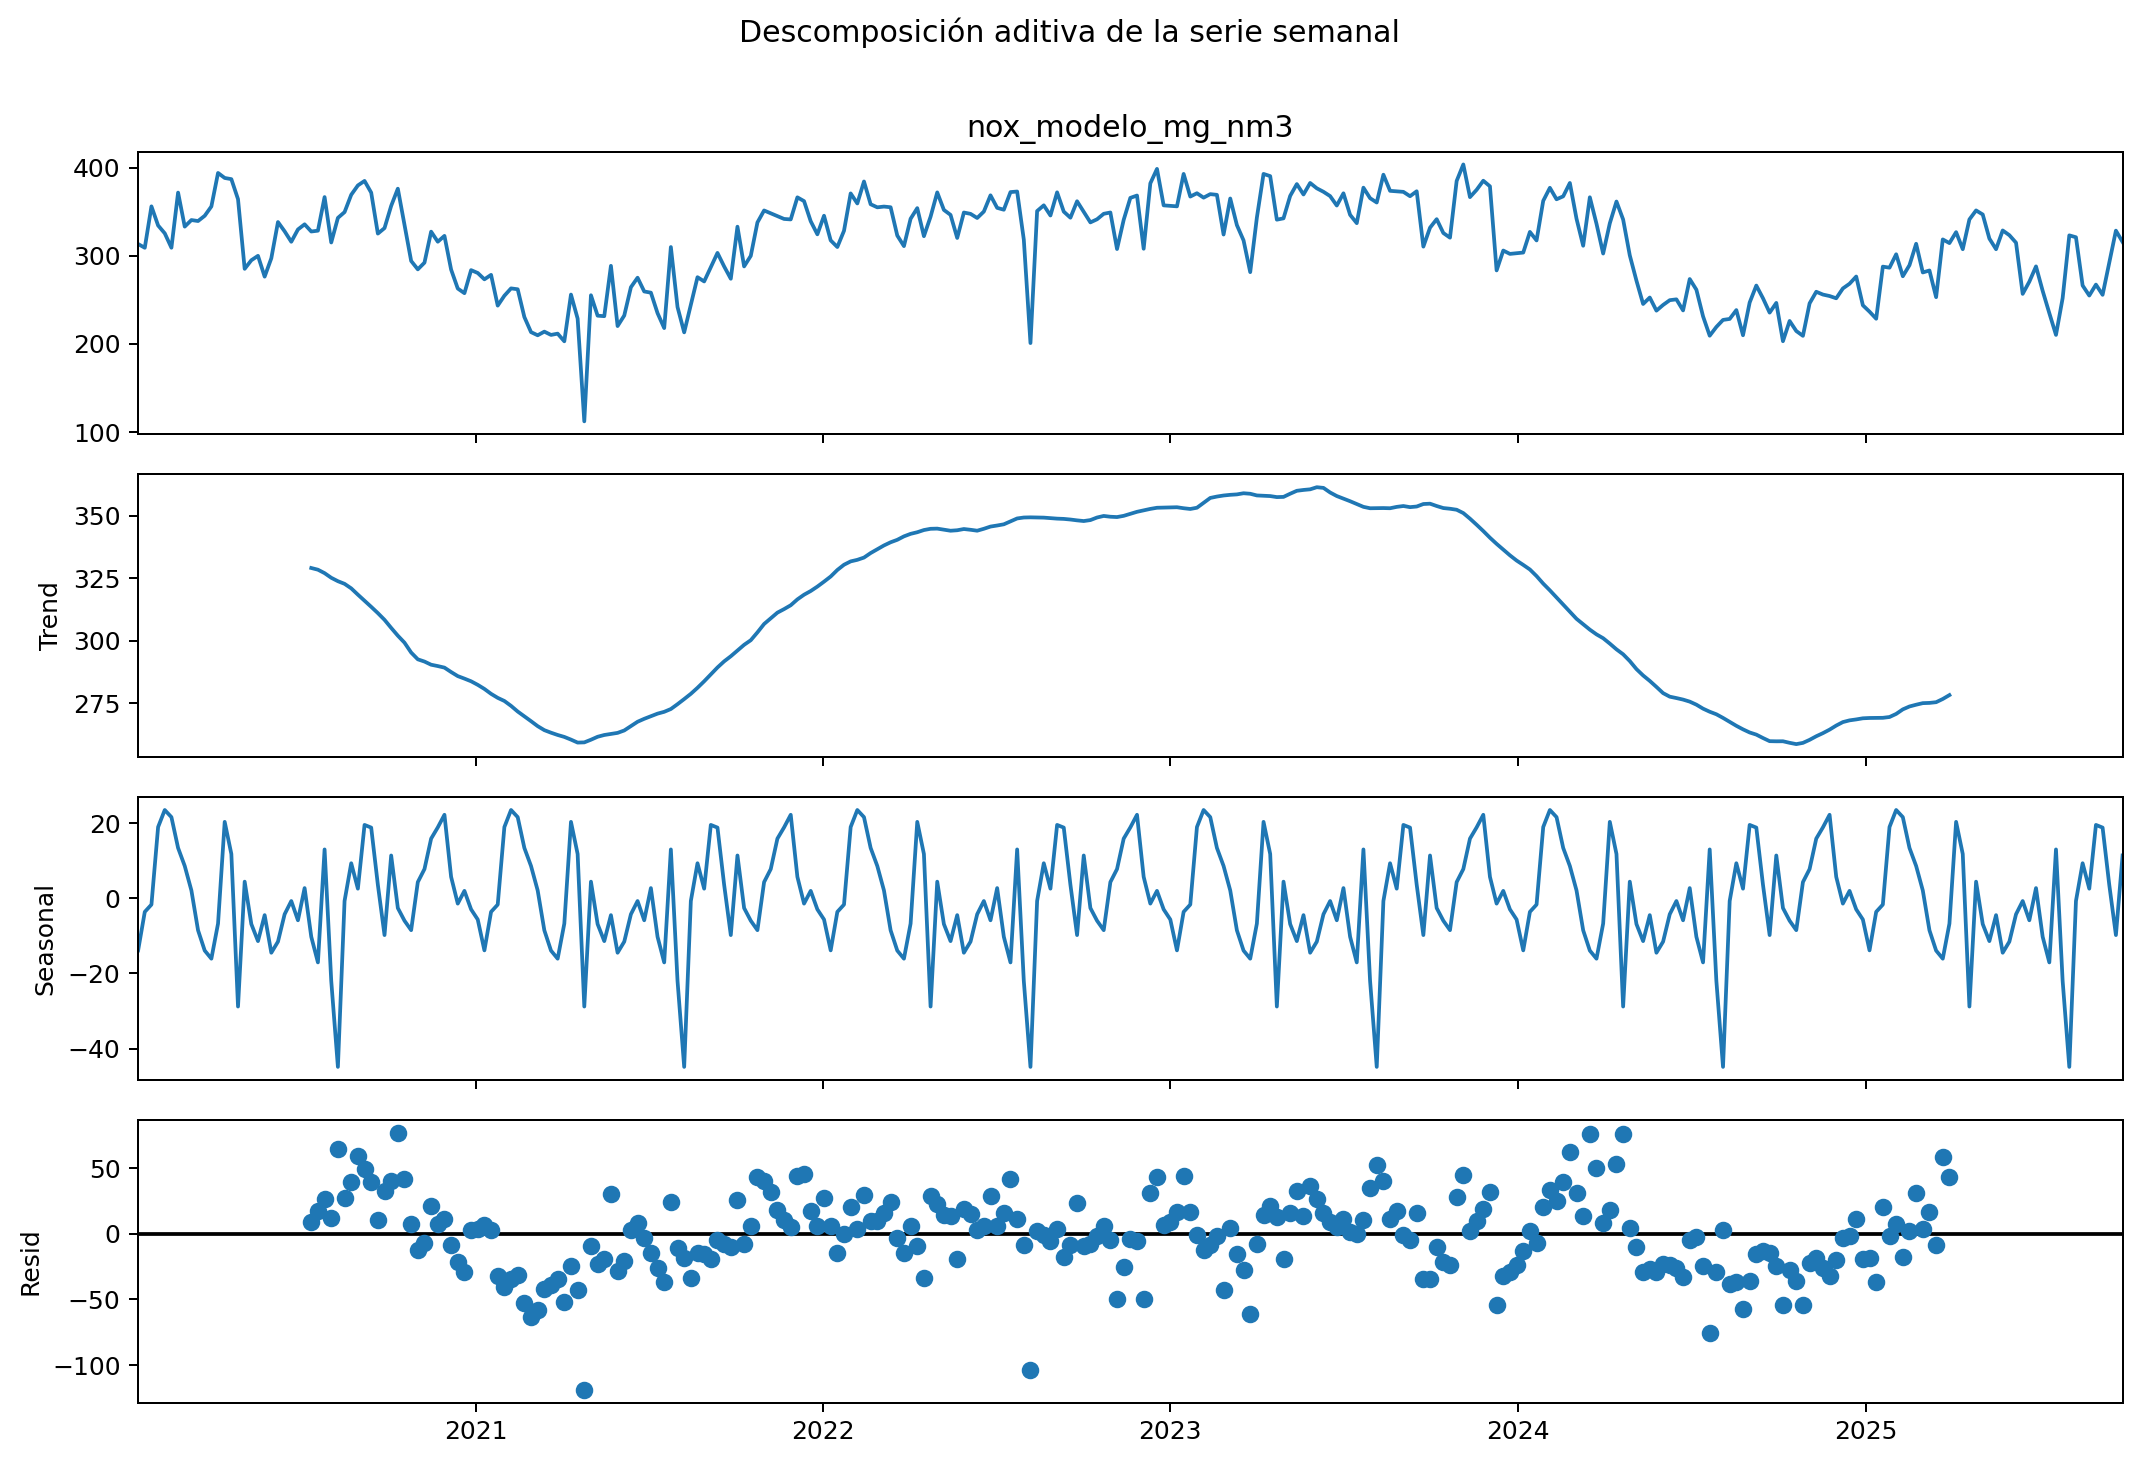

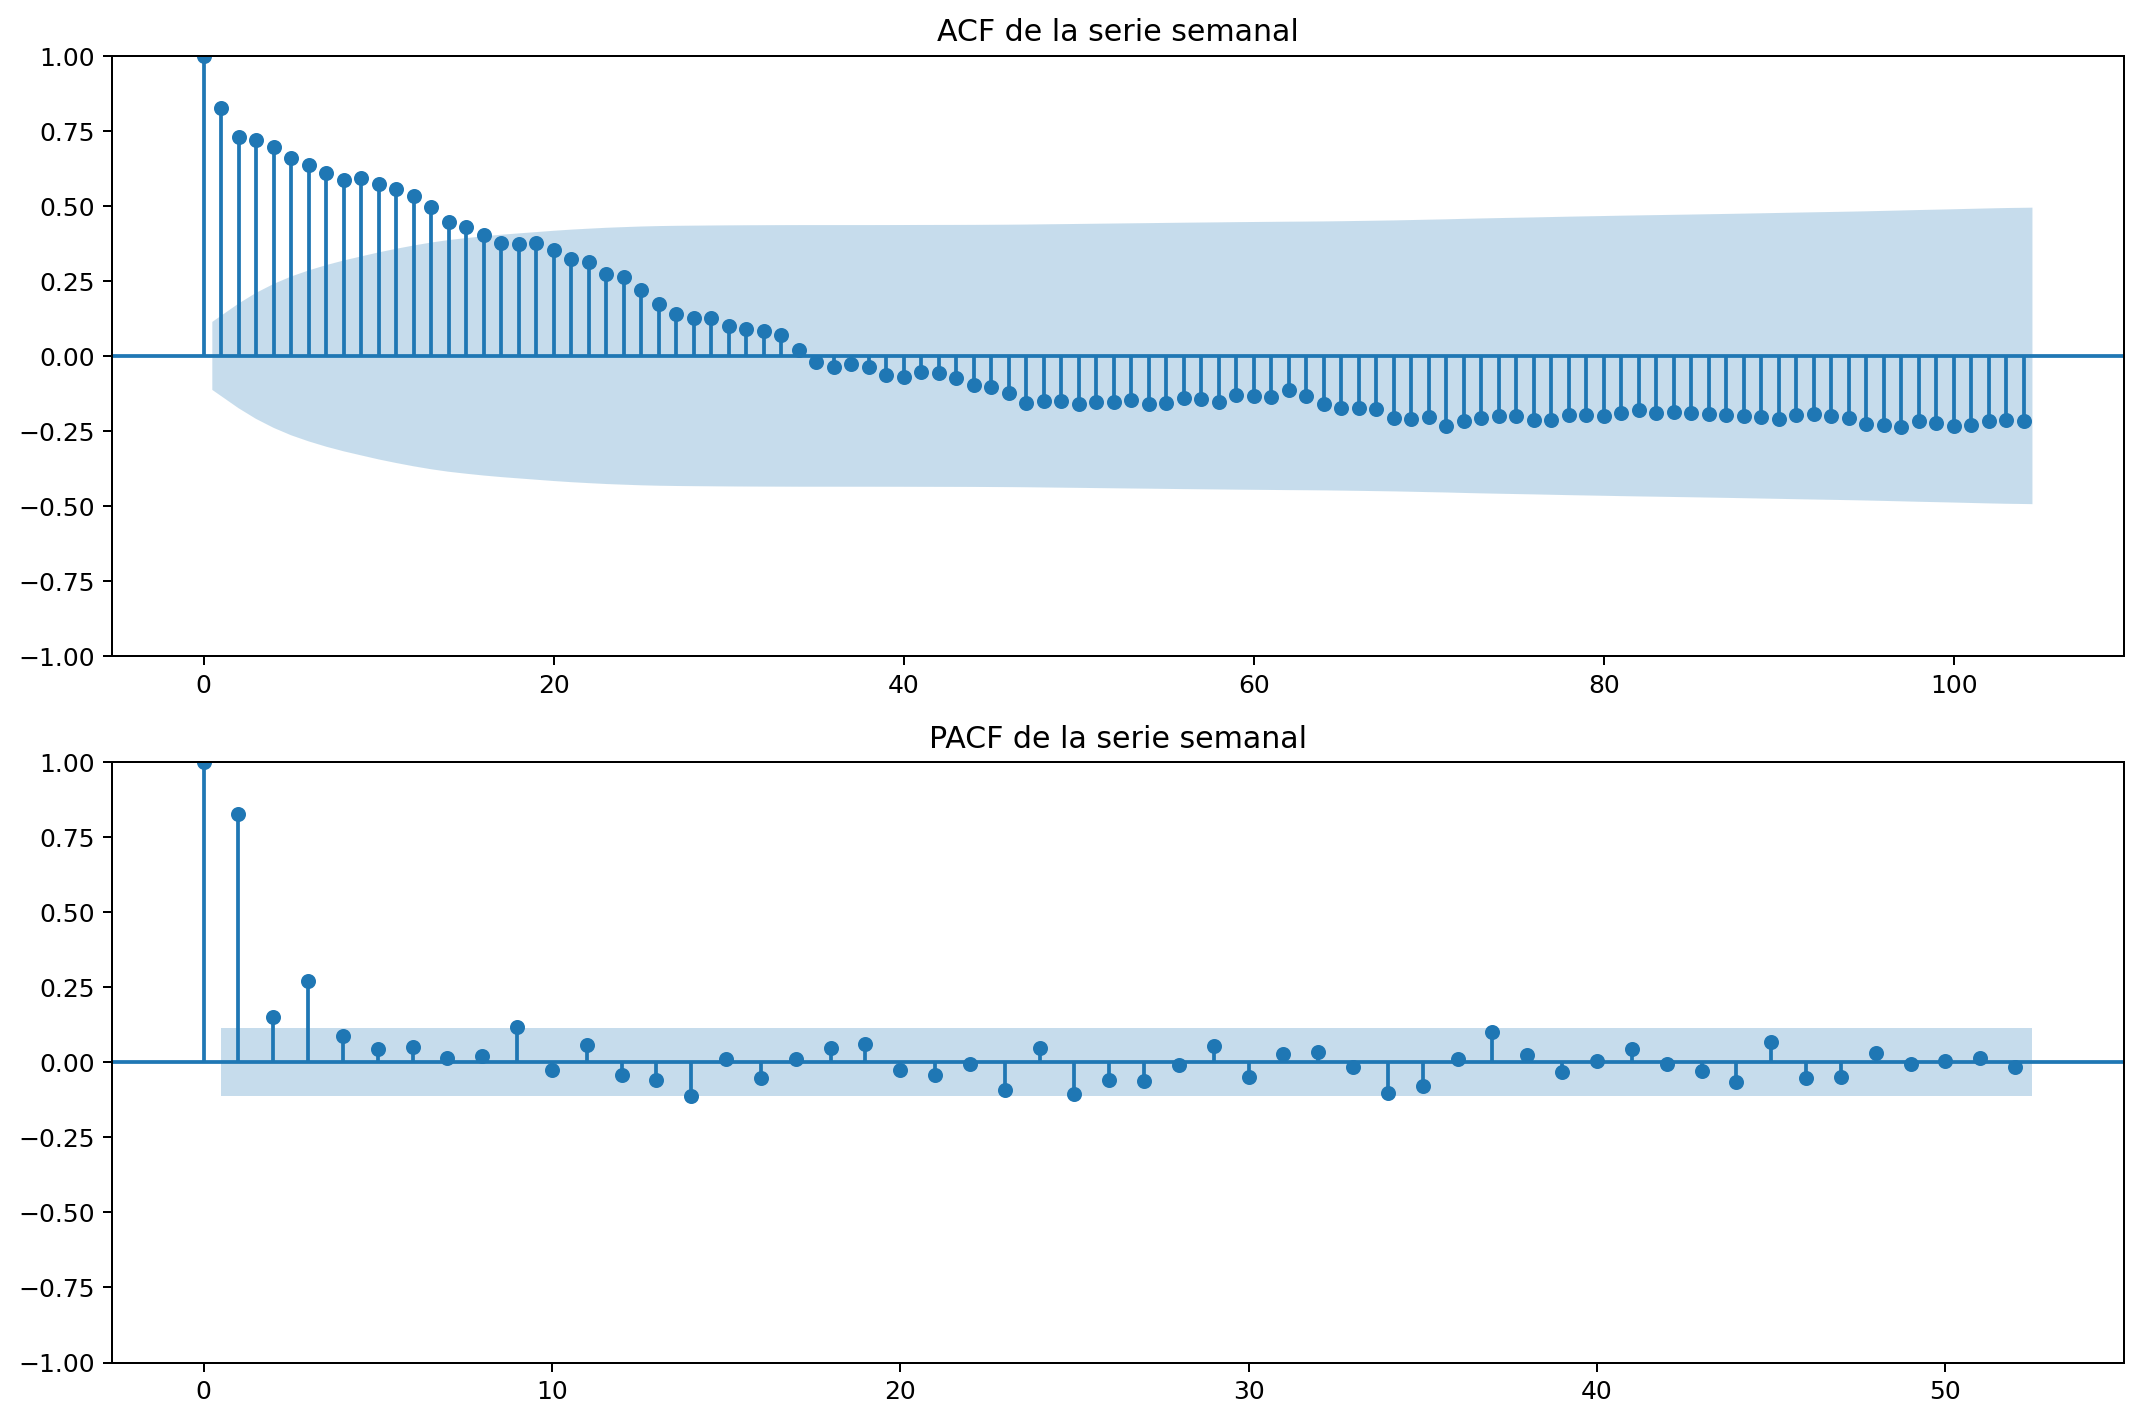

In [5]:
display(Image(filename=str(FIGURES / "01_serie_historica.png")))
display(semanal["nox_modelo_mg_nm3"].describe().to_frame("NOx mg/NmÂ³"))
display(Image(filename=str(FIGURES / "02_descomposicion.png")))
display(Image(filename=str(FIGURES / "03_acf_pacf.png")))

### InterpretaciÃ³n exploratoria

La serie fluctÃºa alrededor de 312,24 mg/NmÂ³, con una desviaciÃ³n estÃ¡ndar semanal de 52,68 mg/NmÂ³. Se observan cambios de nivel y episodios de mayor volatilidad, pero no una tendencia monotÃ³nica persistente. La ACF indica dependencia temporal de corto plazo y seÃ±ales compatibles con repeticiÃ³n anual; esto justifica comparar modelos de nivel, tendencia y un modelo autorregresivo con rezago 52.

La descomposiciÃ³n es una herramienta descriptiva: no demuestra por sÃ­ sola que exista estacionalidad estable ni que los residuos sean ruido blanco.

In [6]:
serie = semanal["nox_modelo_mg_nm3"].astype(float)
adf = adfuller(serie)
pd.Series({
    "estadÃ­stico ADF": adf[0],
    "p-value": adf[1],
    "n observaciones": adf[3]
})

estadÃ­stico ADF     -2.851612
p-value               0.051271
n observaciones     295.000000
dtype: float64

El ADF entrega un valor p cercano a 0,051. Al nivel convencional de 5% no se rechaza la raÃ­z unitaria, aunque el resultado es limÃ­trofe. Por ello no se toma una decisiÃ³n automÃ¡tica de diferenciaciÃ³n: se comparan modelos capaces de representar persistencia, y el diagnÃ³stico residual decide si la estructura temporal quedÃ³ adecuadamente capturada.

## 5. ParticiÃ³n temporal

La selecciÃ³n usa solamente entrenamiento y validaciÃ³n. La prueba final permanece intacta hasta haber escogido el modelo.

In [7]:
train = serie.iloc[:-(H_VALIDACION + H_PRUEBA)]
validacion = serie.iloc[-(H_VALIDACION + H_PRUEBA):-H_PRUEBA]
prueba = serie.iloc[-H_PRUEBA:]

pd.DataFrame({
    "conjunto": ["Entrenamiento", "ValidaciÃ³n", "Prueba final"],
    "n": [len(train), len(validacion), len(prueba)],
    "inicio": [train.index.min(), validacion.index.min(), prueba.index.min()],
    "fin": [train.index.max(), validacion.index.max(), prueba.index.max()],
})

,conjunto,n,inicio,fin
0,Entrenamiento,259,2020-01-12,2024-12-22
1,ValidaciÃ³n,32,2024-12-29,2025-08-03
2,Prueba final,8,2025-08-10,2025-09-28


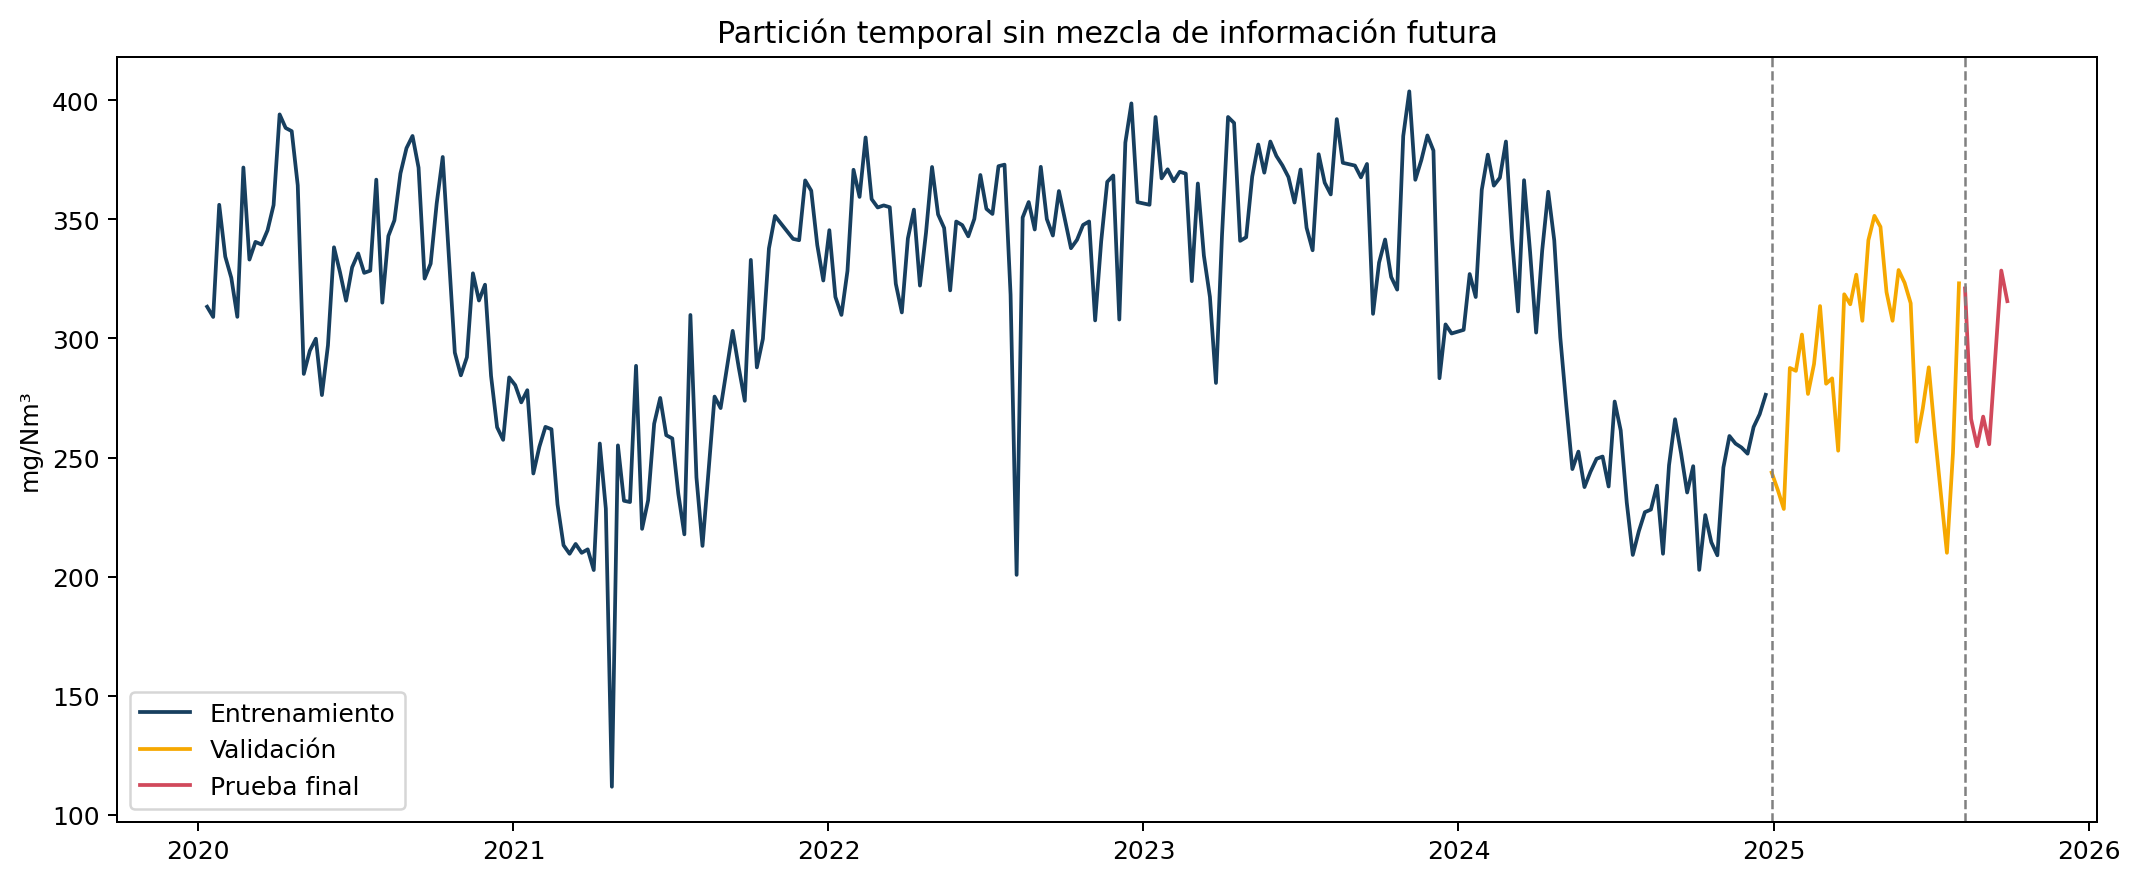

In [8]:
display(Image(filename=str(FIGURES / "04_particion_temporal.png")))

## 6. Modelos y criterio de selecciÃ³n

Se comparan:

1. ingenuo de Ãºltimo valor;
2. ingenuo estacional de 52 semanas;
3. drift;
4. suavizamiento exponencial simple;
5. Holt amortiguado;
6. ETS aditivo con periodo 52;
7. AutoReg con rezagos 1, 2, 3, 4 y 52.

**Regla previa:** exigir `Ljung-Box p > 0,05` en residuos de entrenamiento y, entre los modelos que cumplan, escoger el menor RMSE de validaciÃ³n. El AIC se informa solo como apoyo dentro de modelos probabilÃ­sticos; no se usa para comparar directamente familias diferentes.

In [9]:
# Descomentar para recalcular todos los modelos y actualizar las salidas.
# %run ../ejecutar_modelado_final.py
# %run ../integrar_autoreg.py

comparacion = pd.read_csv(TABLES / "07_comparacion_validacion.csv")
display(comparacion.style.format({
    "RMSE": "{:.2f}", "MAE": "{:.2f}", "MAPE": "{:.2f}",
    "sMAPE": "{:.2f}", "AIC": "{:.2f}", "Ljung_Box_p_10": "{:.4f}"
}))

,modelo,RMSE,MAE,MAPE,sMAPE,AIC,Ljung_Box_p_10,ranking_RMSE
0,Ingenuo último valor,38.93,33.40,11.51,11.71,nan,0.0000,1
1,Drift,39.91,34.09,11.65,11.96,nan,0.0000,2
2,AutoReg rezagos 1-4 y 52,40.02,31.98,11.76,11.14,1987.14,0.7727,3
3,Holt amortiguado,41.93,36.13,12.20,12.71,1754.43,0.0759,4
4,SES,41.93,36.15,12.20,12.71,1748.37,0.0768,5
5,ETS aditivo 52,49.07,38.57,13.22,13.67,2301.06,0.0000,6
6,Ingenuo estacional 52,60.39,50.50,17.49,16.98,nan,0.0000,7


El baseline ingenuo obtuvo el menor RMSE, pero sus residuos conservaron autocorrelaciÃ³n (`p < 0,001`), por lo que no se considerÃ³ apropiado como modelo final. AutoReg quedÃ³ tercero por RMSE, presentÃ³ el menor MAE entre los candidatos competitivos y superÃ³ holgadamente Ljung-Box. De acuerdo con la regla declarada previamente, se seleccionÃ³ **AutoReg con rezagos 1â€“4 y 52**.

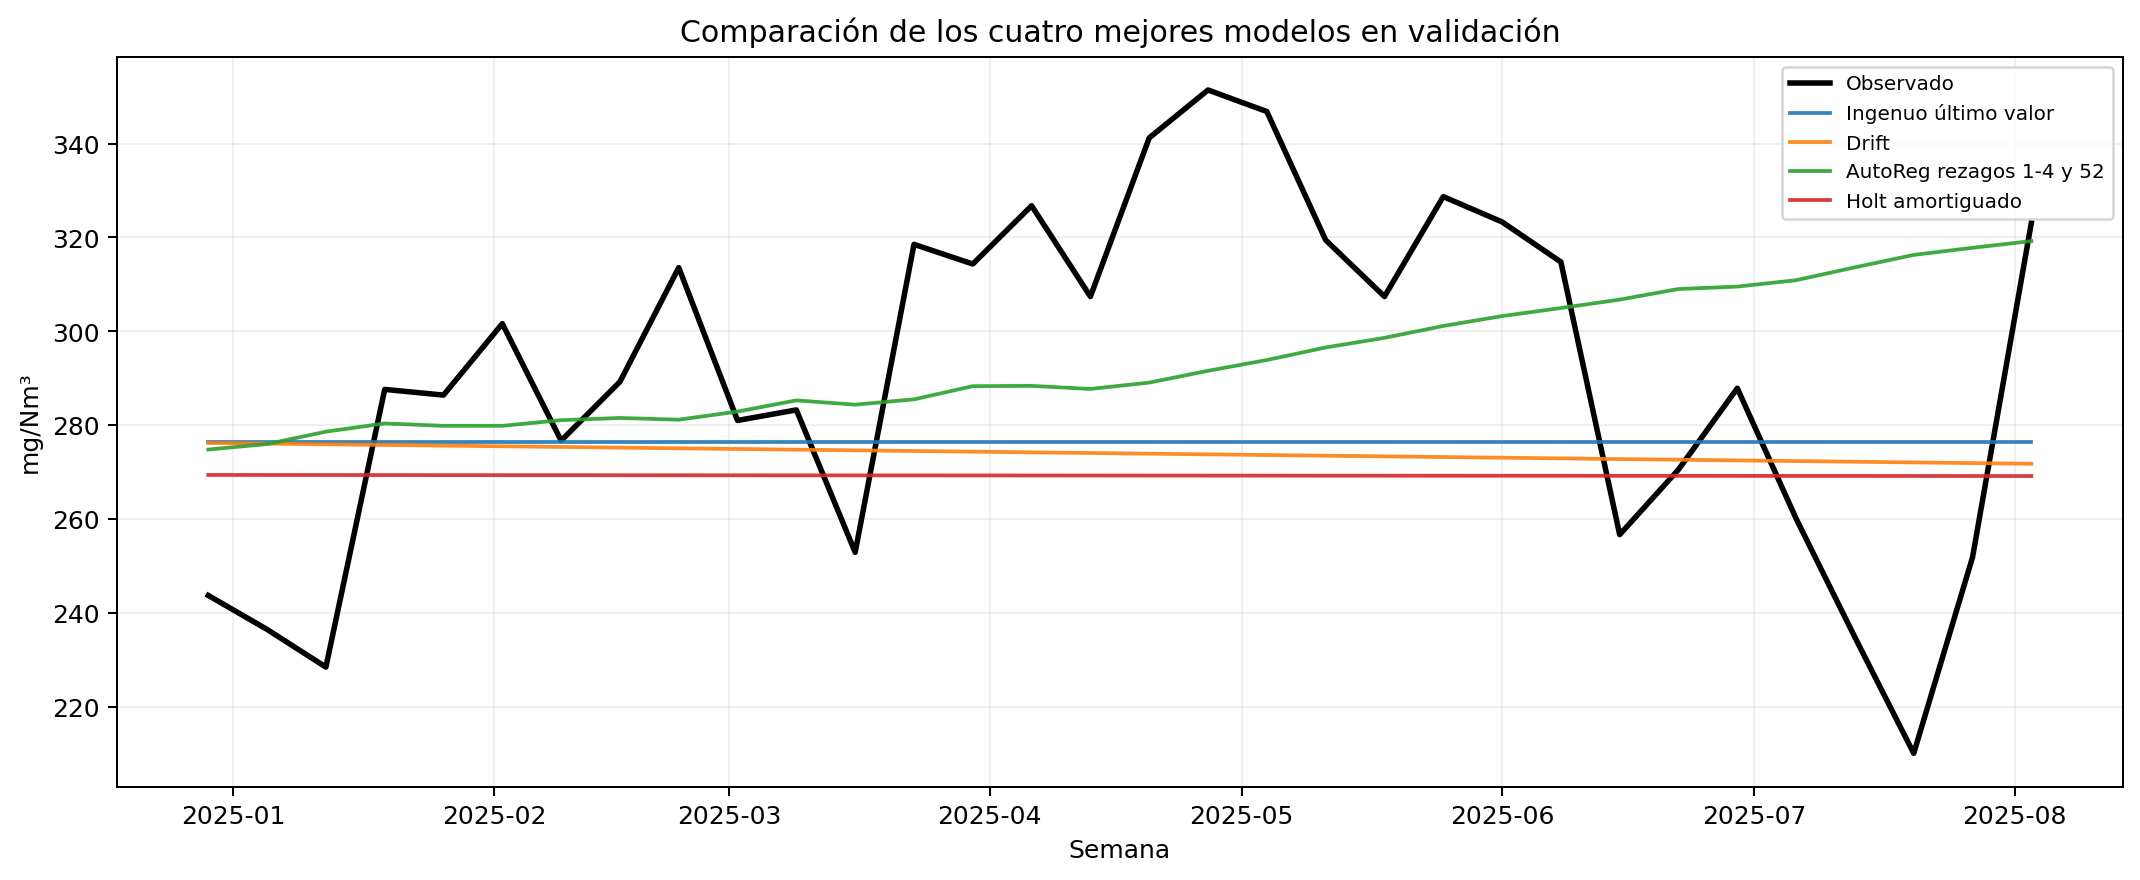

,modelo,RMSE,MAE,MAPE,sMAPE
0,AutoReg rezagos 1-4 y 52,27.533646,24.698774,8.519916,8.545507


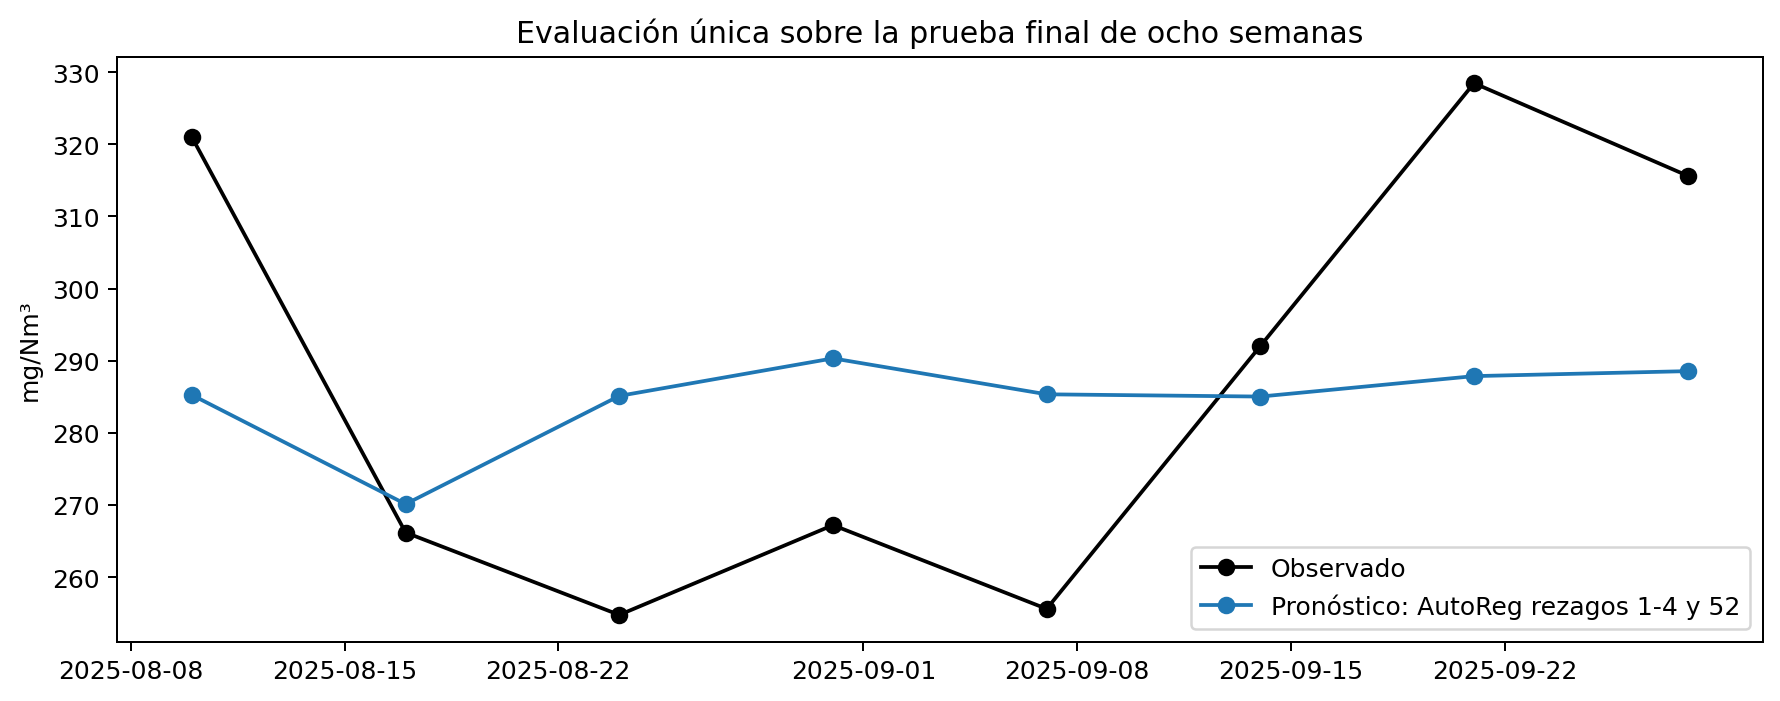

In [10]:
display(Image(filename=str(FIGURES / "05_validacion_modelos.png")))
metricas_prueba = pd.read_csv(TABLES / "08_metricas_prueba_final.csv")
display(metricas_prueba)
display(Image(filename=str(FIGURES / "06_prueba_final.png")))

## 7. EvaluaciÃ³n final y diagnÃ³stico

En las ocho semanas de prueba, el modelo seleccionado alcanzÃ³ RMSE 27,53 mg/NmÂ³, MAE 24,70 mg/NmÂ³, MAPE 8,52% y sMAPE 8,55%. Estos resultados no se utilizaron para cambiar el modelo.

Tras reentrenar con las 299 semanas, Ljung-Box entregÃ³ valores p de 0,713 en el rezago 10 y 0,801 en el rezago 20. No se rechaza la hipÃ³tesis de ausencia de autocorrelaciÃ³n residual, por lo que el modelo final se considera apropiado respecto de la blancura.

,lag,lb_stat,lb_pvalue
0,10,7.130953,0.713027
1,20,14.562962,0.800845


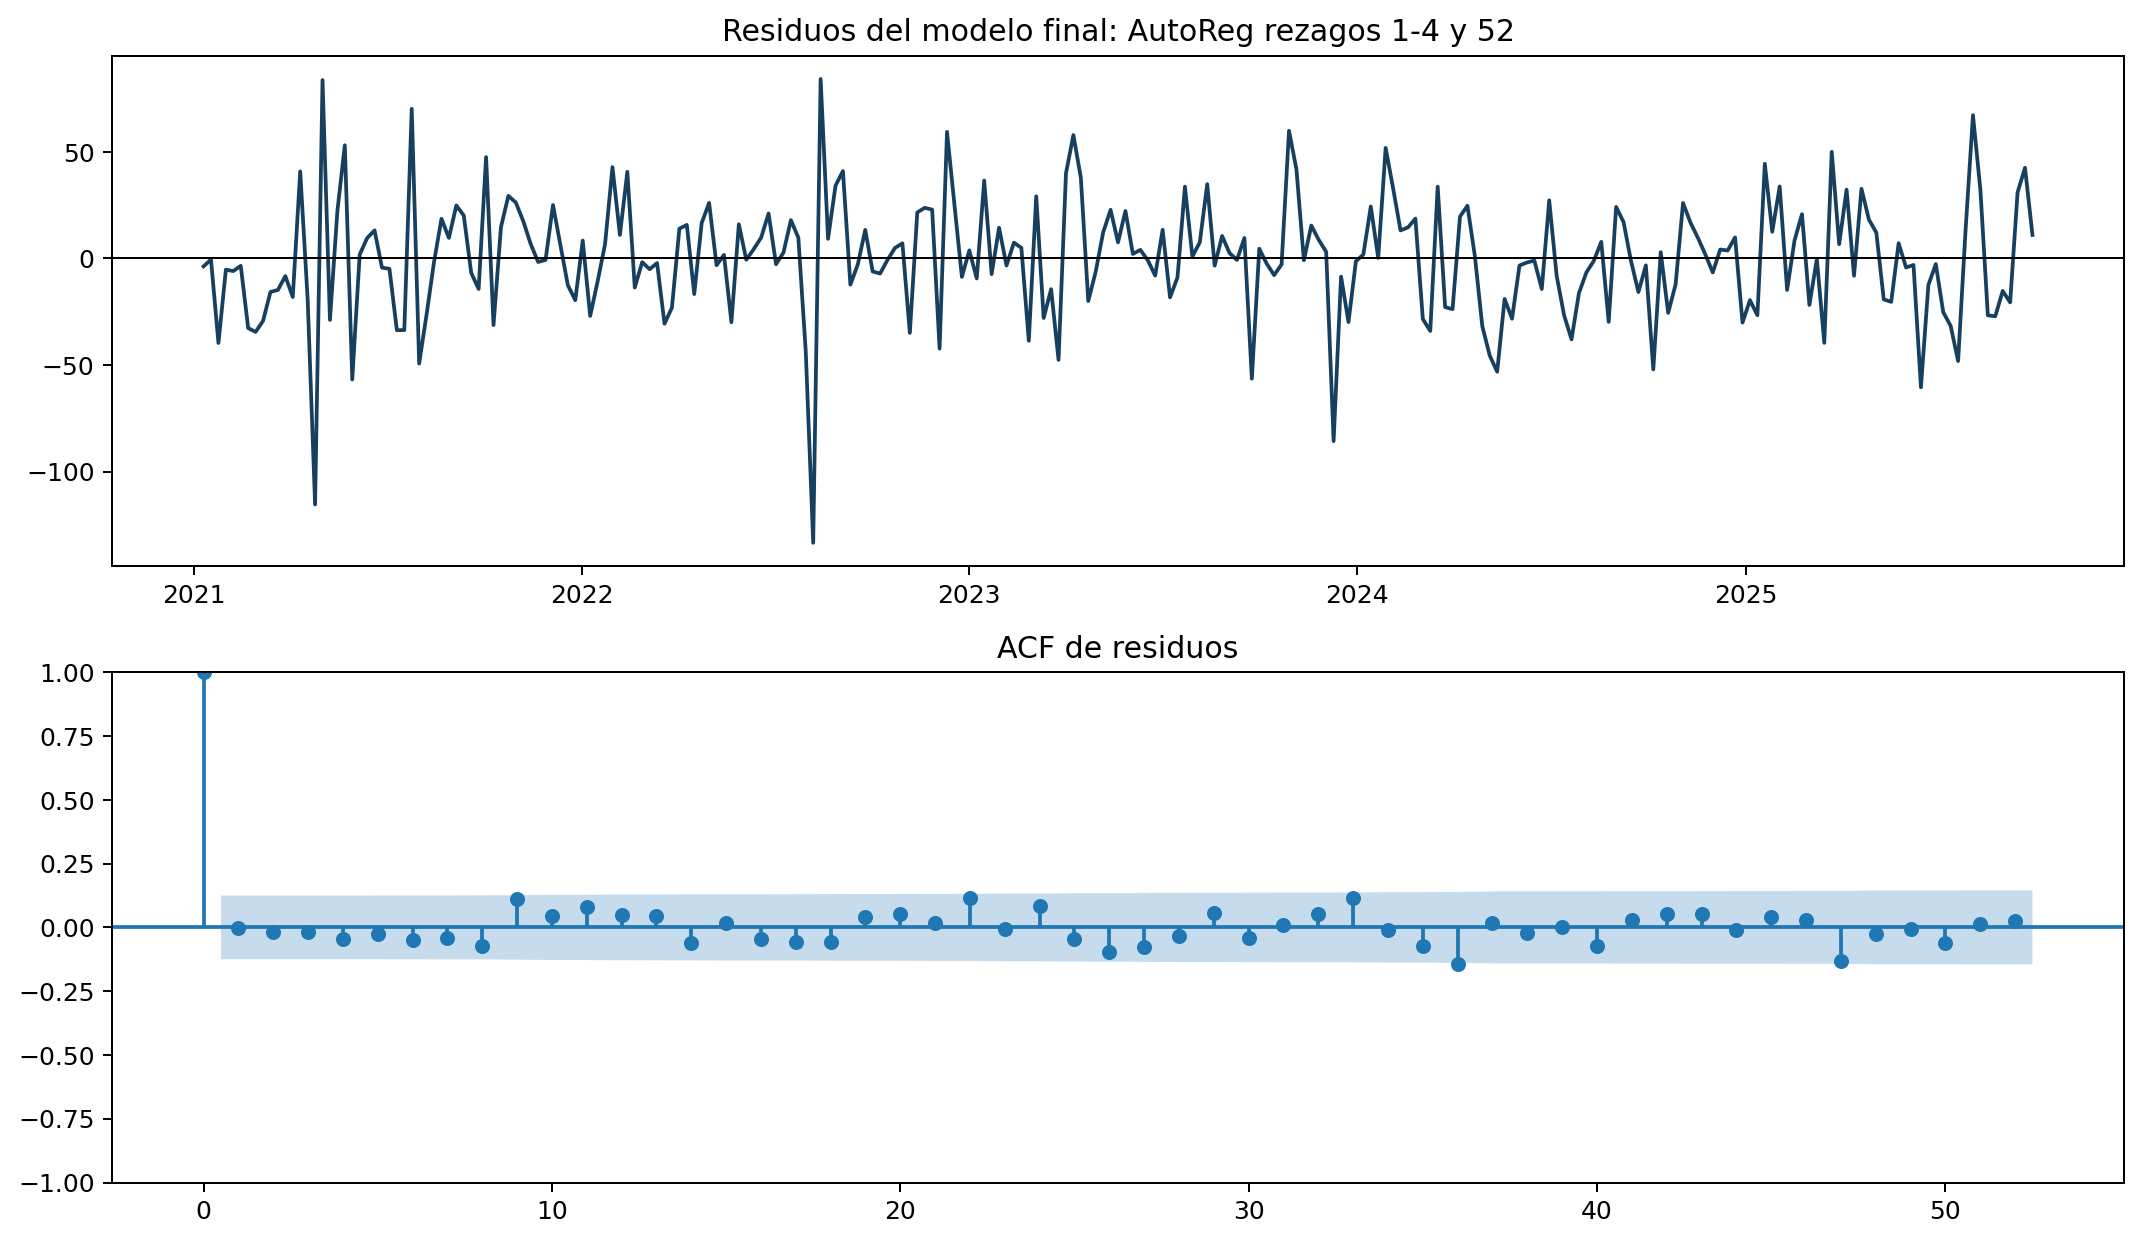

In [11]:
ljung = pd.read_csv(TABLES / "10_ljung_box_modelo_final.csv")
display(ljung)
display(Image(filename=str(FIGURES / "08_diagnostico_residuos.png")))

## 8. PronÃ³stico de ocho semanas

El modelo se reentrena con toda la serie y se proyectan ocho semanas. Los intervalos predictivos del 95% aumentan con el horizonte, reflejando la incertidumbre acumulada.

,semana_fin,pronostico_nox_mg_nm3,limite_inferior_95,limite_superior_95,modelo,metodo_intervalo
0,2025-10-05,304.139133,248.431227,359.847039,AutoReg rezagos 1-4 y 52,Intervalo predictivo normal del modelo AutoReg...
1,2025-10-12,309.752320,244.608851,374.895790,AutoReg rezagos 1-4 y 52,Intervalo predictivo normal del modelo AutoReg...
2,2025-10-19,313.872701,246.222172,381.523230,AutoReg rezagos 1-4 y 52,Intervalo predictivo normal del modelo AutoReg...
3,2025-10-26,312.175788,240.496937,383.854638,AutoReg rezagos 1-4 y 52,Intervalo predictivo normal del modelo AutoReg...
4,2025-11-02,310.746294,234.094284,387.398304,AutoReg rezagos 1-4 y 52,Intervalo predictivo normal del modelo AutoReg...
5,2025-11-09,311.270003,231.195472,391.344535,AutoReg rezagos 1-4 y 52,Intervalo predictivo normal del modelo AutoReg...
6,2025-11-16,311.634815,228.964097,394.305534,AutoReg rezagos 1-4 y 52,Intervalo predictivo normal del modelo AutoReg...
7,2025-11-23,311.340634,226.166071,396.515197,AutoReg rezagos 1-4 y 52,Intervalo predictivo normal del modelo AutoReg...


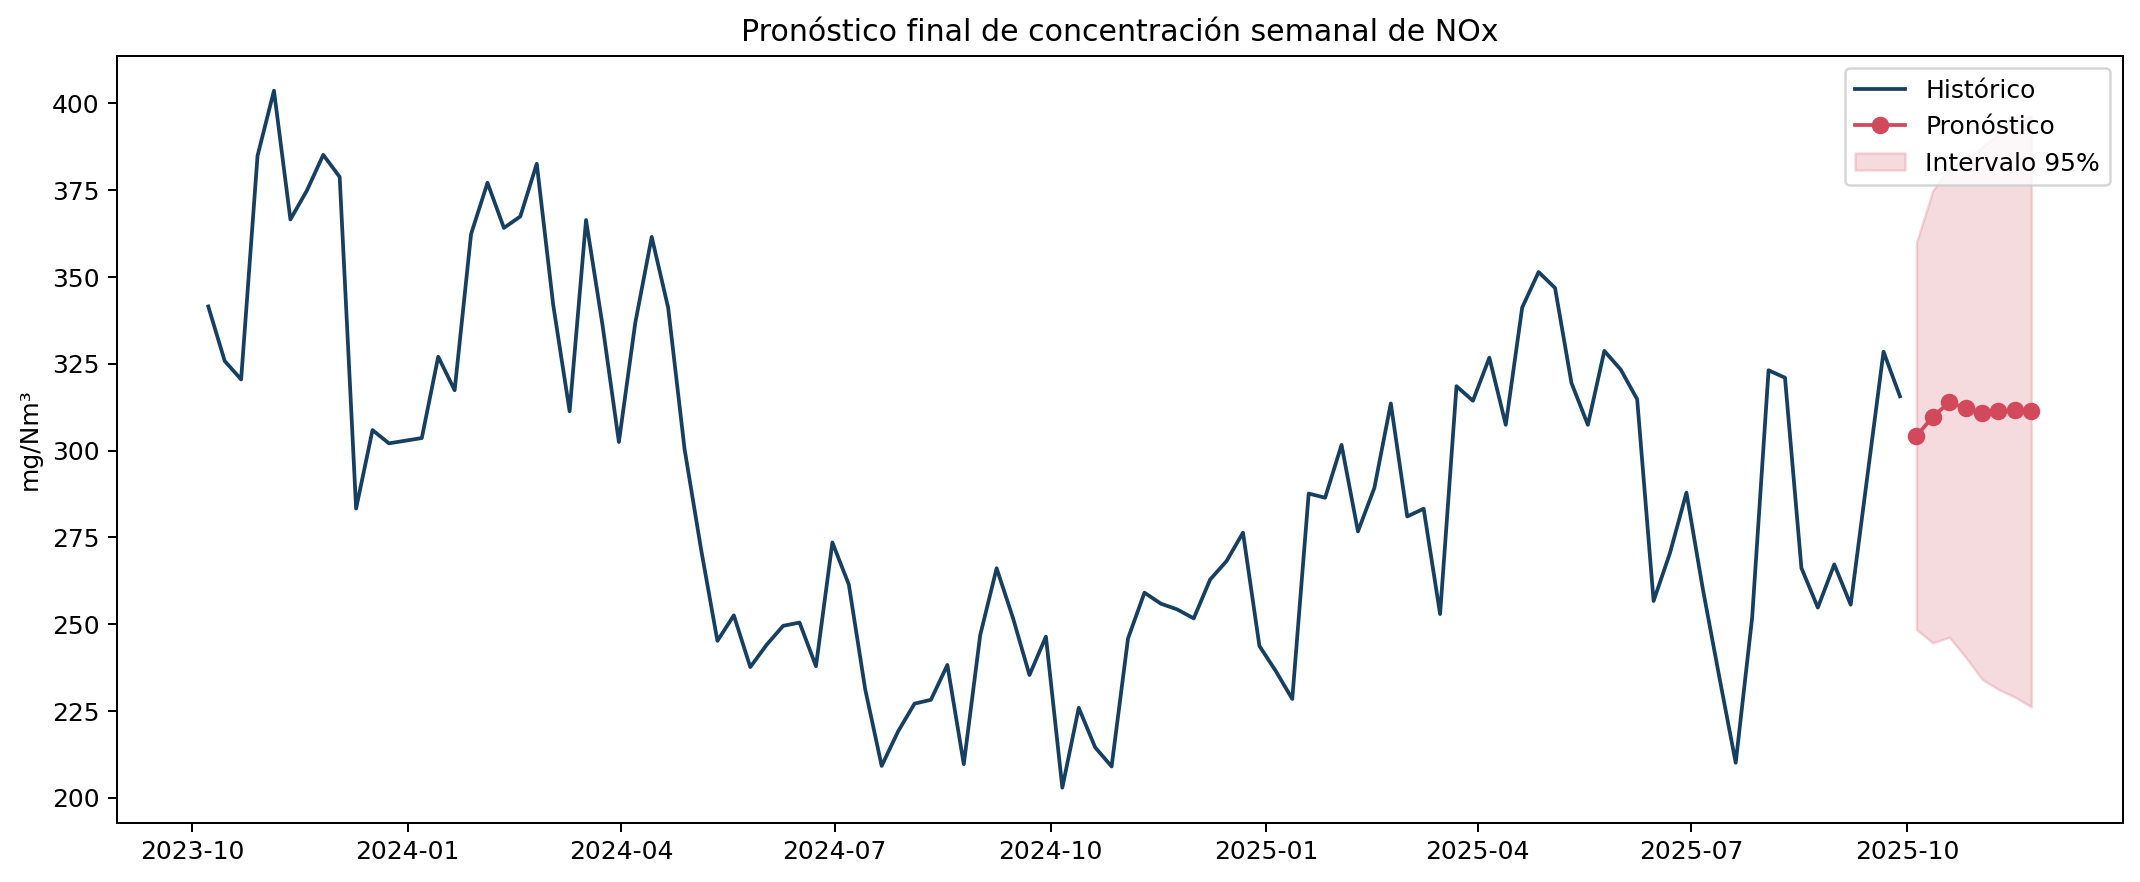

In [12]:
pronostico = pd.read_csv(
    TABLES / "09_pronostico_final_8_semanas.csv",
    parse_dates=["semana_fin"]
)
display(pronostico)
display(Image(filename=str(FIGURES / "07_pronostico_final.png")))

## 9. Conclusiones y limitaciones

- La serie disponible es utilizable y presenta alta cobertura desde 2020 hasta septiembre de 2025.
- Un modelo sencillo de Ãºltimo valor pronostica razonablemente, pero no elimina la dependencia temporal.
- AutoReg con rezagos cortos y anual ofrece el mejor compromiso entre error, parsimonia y residuos blancos.
- El nivel central esperado para las ocho semanas siguientes se mantiene aproximadamente entre 304 y 314 mg/NmÂ³.
- Los intervalos son amplios; las predicciones deben interpretarse como concentraciÃ³n media semanal, no como masa emitida ni como evaluaciÃ³n de cumplimiento normativo.
- La SMA seÃ±ala que los datos son reportados por los regulados y no necesariamente han sido procesados o verificados por la instituciÃ³n.

**Pendiente antes de entregar:** confirmar en el diccionario oficial el significado exacto de todos los cÃ³digos `ESTADO_UGE` y `TIPO_DATO_NOX`, revisar redacciÃ³n y agregar las referencias bibliogrÃ¡ficas finales.

## 10. Archivos de entrega

- Notebook: `Trabajo_Final_Series_Tiempo.ipynb`.
- Base horaria filtrada: `data/angamos1_nox_horaria_filtrada.csv`.
- Base semanal utilizada: `data/angamos1_nox_semanal_modelo.csv`.
- Informe ejecutivo: `INFORME_EJECUTIVO.md`.
- Tablas y figuras reproducibles: `resultados/`.

ConversiÃ³n sugerida a Word:

```bash
pandoc INFORME_EJECUTIVO.md -o INFORME_EJECUTIVO.docx --resource-path=.
```